### 분류 모델
- 분류: 범주를 예측하는 모델
- 종류
    - 이진 분류: 상승/하락, 스팸 여부, 연체 여부 등과 같이 두 가지 범주로 분류할 수 있는 경우
    - 다중 분류: 섹터 예측, 신용 등급등과 같이 여러 가지 범주로 분류할 수 있는 경우

> **이진 분류**가 지표가 명확하고 가장 많이 사용되는 형태 \
> 우리가 가진 데이터(시세)에서 `수익률`, `거래량 비율`, `이평대비`, `변동성` 데이터들로 상승(up)/하락(down)으로 분류할 수 있다!

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, time_split, FEATURES, SEED

setup()
pd.set_option("display.width", 130)
df = build_dataset()
train, test, cutoff = time_split(df)

tr = train.sample(15000, random_state=SEED)
te = test.sample(4000, random_state=SEED)
X_train, y_train = tr[FEATURES], tr["target_up"]
X_test, y_test = te[FEATURES], te["target_up"]

print(f"・학습 {len(tr):,}행 ({tr['date'].min().date()} ~ {tr['date'].max().date()})")
print(f"・테스트 {len(te):,}행 ({te['date'].min().date()} ~ {te['date'].max().date()})")

・학습 15,000행 (2023-10-24 ~ 2026-01-16)
・테스트 4,000행 (2026-01-19 ~ 2026-09-07)


### 분류 알고리즘(모델) 종류: 대표적인 6가지
> 모든 알고리즘은 동일한 방식으로 사용할 수 있다

```python
model = 어떤모델()

model.fit(X_train, y_train)
pred = model.predict(X_test)
score = model.score(X_test, y_test)
```

- 모델 종류
    1. LogisticRegression (로지스틱 회귀 모델): 선형 회귀 방식을 분류에 적용한 모델 \
    ; 데이터가 어떤 범주에 속할 확률을 0과 1 사이의 값으로 예측
        - 스케일링이 필요하며, 다른 모델들 중에 속도가 빠른 편에 속한다
        - 결과 해석이 용이하지만 성능은 보통 수준이다
    2. DecisionTree (의사결정 나무) \
    : 스무고개 하듯이 데이터의 특징(피처, 입력값)을 기준으로 질문을 던져가며 데이터를 분류하는 트리 구조의 모델
        - 스케일링이 불필요하고, 속도가 빠른 편에 속한다
        - 모델 해석이 쉬운 편이나, 과적합되기 쉽기 때문에 단일 모델로는 성능이 비교적 낮은 편에 속한다
    3. KNN (K-Nearest-Neighbors、K-최근접 이웃) \
    : 새로운 데이터를 예측할 때, 주변에 가장 가까이 있는 K개의 이웃 데이터들이 속한 범주를 다수결로 판별하는 방식
        - 거리 기반으로 스케일링이 필수적이다
        - 학습은 없지만 예측 속도가 느리고, 해석은 제한적이며 성능은 보통 수준이다
    4. RandomForest (랜덤 포레스트) \
    : 여러 개의 의사결정 나무를 만들고, 이들의 예측 결과를 취합하여 최종 결과를 도출하는 앙상블 기법
        - 스케일링이 불필요하며 속도는 보통인 편이다
        - 트리가 여러 개라서 단일 트리에 비해 해석은 제한적이지만, 성능이 매우 좋고 안정적이다
    5. SVM (Support Vector Machine): 클래스들을 구분하는 최적의 경계선을 찾는 알고리즘 \
    ; 경계에서 가장 가까운 데이터와의 마진을 최대화한다
        - 스케일링이 필요하며 학습 및 예측 속도가 매우 느린 편이다
        - 내부가 블랙박스 같아 모델 해석이 어렵지만, 데이터에 따라 매우 뛰어난 성능을 발휘하기도 한다
    6. GradientBoosting (그래디언트 부스팅): 이전 트리가 만든 예측의 오차를 다음 트리가 보완하는 방식
    ; 여러 개의 트리를 순차적으로 학습시키는 앙상블 기법 \
        - 스케일링이 불필요하며, 트리를 순차적으로 만들기 때문에 속도는 느린 편이다
        - 해석은 제한적이나 ML 알고리즘 중 비교적 높은 수준의 성능을 보여준다

In [3]:
# 모델별로 성능을 비교해보자!
# =============================================================================
from sklearn.dummy import DummyClassifier
    # 다른 모델 성능을 비교할 기준선을 만드는 분류기
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    # 앙상블 기법(모델)、여러 개의 알고리즘이 합쳐진 모델
from sklearn.linear_model import LogisticRegression
    # 선형 모델
from sklearn.neighbors import KNeighborsClassifier
    # KNN 모델
from sklearn.tree import DecisionTreeClassifier
    # 의사결정 나무
from sklearn.svm import SVC
    # svm 모델
from sklearn.preprocessing import StandardScaler
    # 각 피처의 평균을 0、표준편차를 1로 변경해주는 도구
from sklearn.pipeline import Pipeline
    # 전처리 ~ 모델 학습 과정을 하나로 묶어주는 용도의 도구
from sklearn.metrics import accuracy_score, f1_score
    # accuracy_score (정확도), f1_score (정밀도)

# 스케일링이 필요한 모델은 Pipeline으로 묶어주기
def with_scaler(model):
    return Pipeline([
        ("sc", StandardScaler()),
        ("m", model)
    ])

# SVM ⇒ 데이터 수의 제곱에 비례해서 느려진다 / 표본을 줄여서 사용한다
SVM_N = 3000

# "모델명": (모델객체, 표본수_변경여부)
models = {
    "DummyClassifier": (DummyClassifier(strategy="most_frequent"), False),
    "LogisticRegression": (with_scaler(LogisticRegression(max_iter=1000, random_state=SEED)), False),
    "DicisionTree (제한 X)": (DecisionTreeClassifier(random_state=SEED), False),
    "DicisionTree (제한 O)": (DecisionTreeClassifier(max_depth=5, random_state=SEED), False),
    "KNN (k=50)": (with_scaler(KNeighborsClassifier(n_neighbors=50, n_jobs=-1)), False),
    "RandomForest": (RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1), False),
    "GradientBoosting": (GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED), False),
    "SVM (표본 3천개)": (with_scaler(SVC(random_state=SEED)), True)
}

# 결과(rows)를 담기 위함 > {"모델": 모델명, "학습": score, "테스트": score, "f1": f1, "학습시간": 시간}
rows = []
for name, (model, small) in models.items():
    #
    Xtr = X_train.iloc[:SVM_N] if small else X_train
    ytr = y_train.iloc[:SVM_N] if small else y_train
    
    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    fit_time = time.perf_counter() - t0
        # 모델별 학습 시간 기록
    pred = model.predict(X_test)
    rows.append({
        "모델": name,
        "학습": model.score(Xtr, ytr),
        "테스트": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred, zero_division=0),
        "학습시간": fit_time
    })
result = pd.DataFrame(rows)
print(result.round(4).to_string(index=False))

                 모델     학습    테스트     F1   학습시간
    DummyClassifier 0.5069 0.5175 0.0000 0.0194
 LogisticRegression 0.5107 0.4805 0.3859 0.0161
DicisionTree (제한 X) 1.0000 0.5005 0.4893 0.1368
DicisionTree (제한 O) 0.5219 0.4810 0.5245 0.0364
         KNN (k=50) 0.5672 0.5178 0.4708 0.0114
       RandomForest 0.6105 0.4932 0.4269 0.1547
   GradientBoosting 0.5987 0.4960 0.4434 2.0628
       SVM (표본 3천개) 0.5720 0.4915 0.3787 0.1273


### 분류 모델 성능 결과
- **기준 모델(DummyClassifier)**
    - 항상 다수 클래스로만 예측하는 모델 \
      이 모델의 테스트 정확도(0.5175)가 성능 평가의 최소 기준선이 된다
    - 다른 머신러닝 모델들의 정확도가 이보다 낮게 나온다면, 그 모델들은 의미있는 패턴을 찾지 못하고 있는 것이다
- **정확도(Accuracy)와 F1 점수**
    - `Dummy`는 정확도가 높은 편이지만, 한 가지로만 분류했기 때문에 소수 클래스를 맞출 확률이 없어 F1 점수가 **0.0000**이다
    - 반면에, `DecisionTree(제한)`는 정확도가 상대적으로 낮지만 F1 점수는 **0.5245**로 가장 높다
    - 불균형하거나 정제되지 않은 데이터에서는 정확도만 보고 판단하기 보다、F1 점수 등 다른 지표를 함께 확인해야 한다
- **트리의 과적합**
    - `DecisionTree(제한X)`: 학습 정확도 1.0000이라는 것은 학습 데이터를 100% 외웠다는 의미 \
      ; 테스트 결과와의 격차가 가장 크기 때문에 전형적인 과적합 상태를 보여준다 \
      ; 제약(가지치기)의 필요성을 나타낸다
- **알고리즘별 연산 비용(학습 시간) 한계**
    - **GradientBoosting**: 학습 시간이 2.21초가 걸린다 \
    ; 앞의 트리가 만든 오차를 뒤의 트리가 순차적으로 고쳐나가야 하기 때문에、병렬 처리가 불가한 부스팅 알고리즘 특유의 느린 속도를 보여준다
    - **SVM**: 표본(데이터)을 전체의 1/5 수준으로 줄였는데도 0.14초나 걸린다 \
    ; 데이터 수의 제곱 이상으로 연산량이 폭증하는 SVM의 단점을 확인할 수 있다

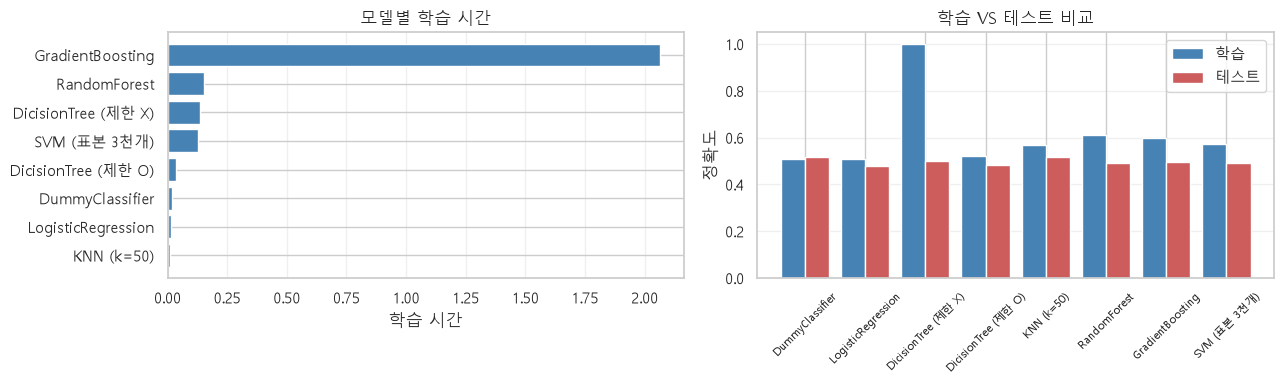

In [6]:
# 시각화하여 비교해보기
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 학습 시간
r = result.sort_values("학습시간")
axes[0].barh(r["모델"], r["학습시간"], color="steelblue")
    # barh: 가로 막대 그래프 (y축, x축)
axes[0].set_xlabel("학습 시간")
axes[0].set_title("모델별 학습 시간")
axes[0].grid(alpha=0.3, axis="x")

# 학습 vs 테스트 정확도 비교
x = np.arange(len(result))
axes[1].bar(x=x - 0.2, width=0.4, height=result["학습"], label="학습", color="steelblue")
axes[1].bar(x=x + 0.2, width=0.4, height=result["테스트"], label="테스트", color="indianred")
    # x: 가로축 위치 조정 (동일한 그래프를 겹치지 않고 표시하기 위해 설정)
    # height: 막대 높이, 표현할 데이터 값
    # width: 막대의 두께(너비)

axes[1].set_xticks(x)
    # x축 눈금의 기본 위치
axes[1].set_xticklabels(result["모델"], rotation=45, fontsize=8)
axes[1].set_ylabel("정확도")
axes[1].set_title("학습 VS 테스트 비교")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

---
## KNN(K-Nearest Neighbors): "가장 가까운 K개의 샘플을 찾아서 다수결로 결정" 할 때 사용되는 방식의 모델
**핵심 원리**: "유유상종" \
> 새로운 데이터가 들어오면, 거리가 가장 가까운 기존 데이터 K개를 찾아 그들이 가장 많이 속한 클래스로 예측한다

### K 값에 따른 모델 제어 (과적합 조절)
- **k 값이 너무 작을 때(Ex. k=1)**: 오직 가장 가까운 1개만 보고 판단하므로、데이터의 사소한 노이즈(이상치)에도 민감하게 반응한다
- 경계선이 복잡해지고 **과적합**이 발생한다
- **k 값이 너무 클 때**: 동네 사람 전체에게 물어보는 것처럼 무조건 다수 클래스로 예측해버리는 둔감한 모델이 된다 \
    너무 단순해져서 **과소적합**이 발생한다
> **적절한 K 값을 찾는 것**이 모델 성능의 핵심이다 !

|장점|단점|
|:--:|:--:|
|개념 단순|예측할 때마다 전체 거리를 계산|
|학습이 사실상 X|예측 시 데이터가 많으면 느리다|
|비선형 경꼐 처리|스케일링이 필수적이다|

> **KNN은 게으른 학습기** \
> 보통의 머신러닝 모델은 `fit()` 단계에서 공식을 만들고, `predict()` 단꼐에서 빠르게 정답을 도출하지만 KNN은 반대이다! \
> `fit()`에서는 훈련 데이터를 저장만 하고, `predict()` 호출이 들어오면 그때 모든 데이터와의 거리를 계산하여 시간이 오래 걸린다

In [7]:
# k값을 변경하면서 학습, 테스트 성능을 비교해보기
ks = [1,3,5,10,15,30,50,100,200,500]
rows = []

for k in ks:
    knn = with_scaler(KNeighborsClassifier(n_neighbors=k, n_jobs=-1))
    knn.fit(X_train, y_train)

    tr_s = knn.score(X_train, y_train)
    te_s = knn.score(X_test, y_test)
    rows.append({"k": k, "학습": tr_s, "테스트": te_s, "차이": tr_s - te_s})
knn_result = pd.DataFrame(rows)
print(knn_result.round(4).to_string(index=False))

  k     학습    테스트     차이
  1 1.0000 0.5052 0.4948
  3 0.7562 0.4892 0.2669
  5 0.6916 0.4940 0.1976
 10 0.6273 0.5042 0.1230
 15 0.6115 0.5135 0.0980
 30 0.5845 0.5220 0.0625
 50 0.5672 0.5178 0.0494
100 0.5510 0.5110 0.0400
200 0.5334 0.4968 0.0366
500 0.5232 0.4938 0.0294


### k 값 변화에 따른 성능 비교

- **k=1일 때**, **극단적인 과적합**
    - 학습 정확도: 1.0000
    - 학습 데이터로 예측을 수행할 때、'자기 자신'이 가장 가까운 1개의 이웃이 되므로 무조건 정답을 맞히게 된다 \
      (답안지를 보고 시험을 푸는 것도 동일)
    - 반면에 테스트 정확도는 0.5052로 매우 낮고 두 값의 차이도 가장 크기 때문에、전형적인 과적합 상태이다

- **k값이 너무 클 때**: **과소 적합**
    - k를 100, 200, 500으로 무작정 키우면 너무 많은 데이터의 결과를 참고하게 된다
    - 결국 데이터의 미세한 특징은 무시된 채 무조건 '가장 많은 다수의 클래스'로만 예측하게 되어 \
      성능이 오히려 떨어지는 과소 적합 상태가 된다
    > **k가 30일 때**, 테스트 정확도가 0.5220으로 가장 높다 \
    > 현재 데이터 기준으로는 30 부근이 과적합과 과소적합 사이의 최적점임을 알 수 있다 \

#### **KNN은 가장 가까운 거리를 구하는 것이기 때문에 항상 `스케일링`이 필수적이다!**
---

### 앙상블 (Ensemble)
: "집단 지성" \
: 단일 모델의 한계를 극복하기 위해 여러 모델의 의견을 모으는 방식

|방식|결합 방법|대표 모델|
|:--:|:--:|:--:|
|보팅|서로 다른 알고리즘을 결합|직접 만들어서 사용|
|배깅|**동일한** 알고리즘을 데이터만 무작위로 다르게 추출하여 **병렬 학습**|RandomForest|
|부스팅|모델을 **순차적으로** 학습시키며 앞 모델의 약점을 보완|GradientBoosting, XGBoost, LightGBM|

**배깅과 부스팅의 차이**
- 배깅은 여러 모델이 **동시에 따로** 학습하고 마지막에 다수결로 의견을 모으는 방식
    - 분산을 줄여 과적합을 막는 전략
- 부스팅은 앞 모델이 **틀린 것을 다음 모델이 집중적으로** 파고들며 순차적으로 학습하는 방식
    - 편향을 줄여 성능을 높이는 전략

In [9]:
# 트리 1개, 배깅, 부스팅 비교
models = {
    "DecisionTree (트리 1개)": DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "RandomForest (배깅)": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1),
    "GradientBoosting (부스팅)": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED),
}
rows = []

for name, m in models.items():
    t0 = time.perf_counter()
    m.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0
    rows.append({
        "모델": name,
        "학습": m.score(X_train, y_train),
        "테스트": m.score(X_test, y_test),
        "학습시간": fit_time
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))

                    모델     학습    테스트   학습시간
  DecisionTree (트리 1개) 0.5279 0.4800 0.0475
     RandomForest (배깅) 0.6105 0.4932 0.1642
GradientBoosting (부스팅) 0.5987 0.4960 2.0801


- **트리 1개보다 여러 개가 더 나은 이유**: 트리 하나는 특정 패턴에 치우쳐질 수 있다 \
  : 서로 다르게 치우 친 트리 여러 개의 의견을 모으면 개별 오차를 줄일 수 있다

- **부스팅은 학습 시간이 더 많이 소요된다**: 배깅은 병렬 처리를 하지만 부스팅은 순차적으로 진행하기 때문에 병렬화가 될 수 없다!
---

## 평가 지표 판단 시, 정확도만으로 판단한다면？
예를 들어, 연체 예측 모델을 만든 경우 정확도가 97%가 확인되었다 (좋은 모델인가？)
> 전체 10,000명 중 연체자 300명 (3%)
> 모델이 전원을 정상 처리하면 > 9,700염을 맞춘다 > 정확도 97% > 연체자 정확도 0%

In [10]:
print(f"{'기준선':>10}{'양성 비율':>12}{'음성 정확도':>18}")
print("-" * 40) # ----------------------------------------

for th in [0.0, 0.01, 0.02, 0.03, 0.04, 0.05]:
    ratio = (df["target_ret"] > th).mean()
    print(f"{th:>9.0%}{ratio:>12.2%}{1-ratio:18.4f}")

       기준선       양성 비율            음성 정확도
----------------------------------------
       0%      48.95%            0.5105
       1%      29.46%            0.7054
       2%      15.30%            0.8470
       3%       6.74%            0.9326
       4%       2.86%            0.9714
       5%       1.38%            0.9862


In [11]:
from sklearn.metrics import precision_score, recall_score

# 수익률을 기준으로 5% 초과를 '급등'으로 지정
TH_P = 0.05
y_tr = (tr["target_ret"] > TH_P).astype(int)
y_te = (te["target_ret"] > TH_P).astype(int)

model = {
    "Dummy (전부 아니다)": DummyClassifier(strategy="most_frequent"),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=6,
                                           random_state=SEED, n_jobs=-1),
    "RandomForest (balanced)": RandomForestClassifier(n_estimators=100, max_depth=6,
                                                      random_state=SEED, n_jobs=-1,
                                                      class_weight="balanced"),
}
rows = []
for name, m in models.items():
    # 학습
    m.fit(X_train, y_tr)
    # 예측
    pred = m.predict(X_test)
    # 평가 > score, accuracy_score, ...
    rows.append({
        "모델": name,
        "정확도": accuracy_score(y_te, pred),
        "정밀도": precision_score(y_te, pred, zero_division=0),
        "재현율": recall_score(y_te, pred, zero_division=0),
        "F1": f1_score(y_te, pred, zero_division=0)
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))

                    모델    정확도  정밀도  재현율  F1
  DecisionTree (트리 1개) 0.9862  0.0  0.0 0.0
     RandomForest (배깅) 0.9868  0.0  0.0 0.0
GradientBoosting (부스팅) 0.9798  0.0  0.0 0.0


> 더미 모델의 정확도가 98% 이상으로 확인된다 \
> 그러나 재현율은 0% 이다 > 찾고자 하는 값을 하나도 못 찾았다! \

> 실제로 우리가 다루게 될 데이터는 불균형 데이터가 많기 때문에、정확도가 높은 것만으로는 아무 의미가 없다 \
> 가장 간단하게 불균형 데이터를 대응하는 방법으로, **class_weight="balanced"** 옵션을 추가하면 소수 클래스에 가중치를 부여해서 재현율이 올라갈 수 있다 \
> 대신 정확도나 정밀도는 떨어질 수 있다
---

### 혼동 행렬 - 모든 지표를 만드는 기준값
- True / False: 예측이 정답과 일치하는지？
- Positive / Negative: 모델이 무엇으로 예측했는지？
    - TP: 양성으로 예측하였고, 정답과 일치　 (성공) >> 정답: 양성
    - FP: 양성으로 예측하였고, 정답과 불일치 (실패) >> 정답: 음성
    - TN: 음성으로 예측하였고, 정답과 일치　 >> 정답: 음성
    - FN: 음성으로 예측하였고, 정답과 불일치 >> 정답: 양성
---

#### 정밀도, 재현율, F1
|지표|계산|질문|
|:--:|:--:|:--:|
|정확도|(TP+TN)/전체|전체중에 얼마나 맞추었는지？|
|정밀도|TP/(TP+FP)|양성이라고 예측한 것들 중 실제로 양성인 것？|
|재현율|TP/(TP+FN)|실제 양성인 것들 중에 예측에 성공한 것？|
|F1|정밀도, 재현율을 조화롭게 평균|둘의 균형(조화 평균)|

- 정밀도 > 양성으로 "예측한 것" 중에 맞춘 것
- 재현율 > "실제" 양성인 것 중에 맞춘 것

In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_te, pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3947
           1       0.00      0.00      0.00        53

    accuracy                           0.98      4000
   macro avg       0.49      0.50      0.49      4000
weighted avg       0.97      0.98      0.98      4000



- accuracy: 정확도
- precision: 정밀도
- recall: 재현율
- f1-score: 정밀도+재현율 조화 평균
- support: 각 클래스 별 실제 건수 (불균형 정도를 파악할 수 있다)
---

### ROC 곡선과 AUC(면적)
- 분류 모델에서는 사실상 **확률**을 출력해준다! `0.5`를 넘으면 양성이라고 판단하고、이하면 음성이라고 판단한다
- 이 기준값(임계값)을 바꾸면 정밀도, 재현율이 함께 움직인다 \
  임계값을 0부터 1까지 바꿔가면서 그린 곡선이 **ROC**이고、그 곡선 아래 면적을 수치화한게 **AUC**이다
- 기준값을 너무 엄격하게 잡으면 > 확실한 경우만 양성으로 판정된다 \
  오탐이 거의 0에 가깝게 수렴하지만 실제로 양성을 놓쳐서 탐지율(TPR)은 바닥으로 떨어질 수 있다
- 기준값을 너무 느슨하게 잡으면 > 양성으로 판정되는 경우가 많아지기 때문에 모든 양성을 찾아내서 탐지율(TPR)은 100%가 될 수 있지만 \
  음성도 양성을 판단하는 오탑(TPR)도 거의 100%가 될 것이다!

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve

# 기준: 수익률 2% 초과
TH = 0.02
y_tr2 = (tr["target_ret"] > TH).astype(int)
y_te2 = (te["target_ret"] > TH).astype(int)
model = RandomForestClassifier(max_depth=6, random_state=SEED,
                               n_jobs=-1, class_weight="balanced")
model.fit(X_train, y_tr2)
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]    # 양성일 확률
auc = roc_auc_score(y_te2, proba)            # ROC 곡선 아래 면적에 해당하는 값을 점수로 환산하여 반환

fpr, tpr, threshold = roc_curve(y_te2, proba)
    # fpr: 가짜 양성 비율
    # tpr: 진짜 양성 비율
    # threshold: 기준값 목록 (fpr, tpr을 계산할 때의 기준값)
print(f"AUC: {auc:.4f}")

AUC: 0.4806


|AUC|해석|
|:--:|:--:|
|1.0|완벽|
|0.8 ~ 0.9|좋음|
|0.7|쓸만함|
|0.5|랜덤과 다를 바가 없는 상태(무작위)|

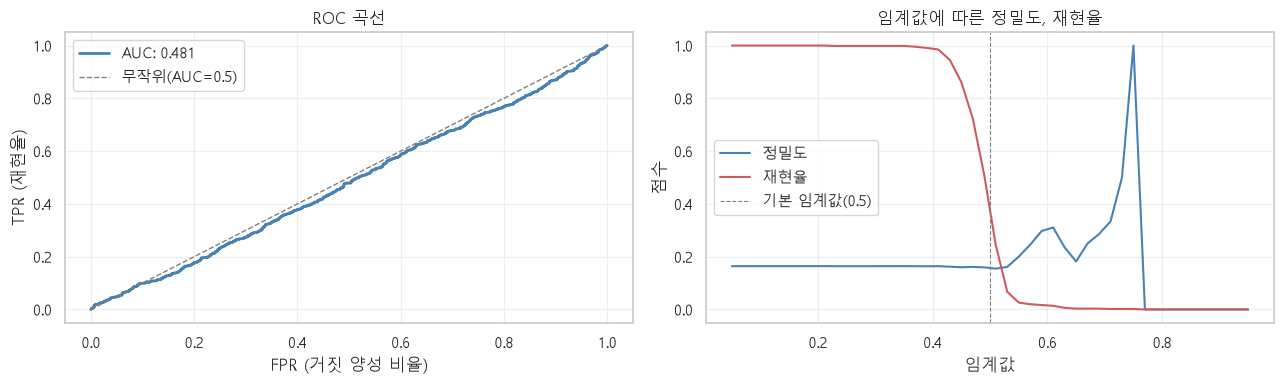

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 1. ROC 곡선 시각화
axes[0].plot(fpr, tpr, lw=2, label=f"AUC: {auc:.3f}", color="steelblue")
axes[0].plot([0,1], [0,1], "--", color="gray", lw=1, label="무작위(AUC=0.5)")
axes[0].set_xlabel("FPR (거짓 양성 비율)")
axes[0].set_ylabel("TPR (재현율)")
axes[0].set_title("ROC 곡선")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. 임계값에 따라서 두 지표(정밀도, 재현율)가 어떻게 바뀌는 지 시각화
ths = np.arange(0.05, 0.96, 0.02)
# 정밀도, 재현율 > proba가 임계값 이상이면 True, 미만이면 False
pres = [precision_score(y_te2, (proba >= t).astype(int), zero_division=0) for t in ths]
recs = [recall_score(y_te2, (proba >= t).astype(int), zero_division=0) for t in ths]
axes[1].plot(ths, pres, label="정밀도", color="steelblue")
axes[1].plot(ths, recs, label="재현율", color="indianred")
axes[1].axvline(0.5, color="gray", ls="--", lw=0.8, label="기본 임계값(0.5)")
axes[1].set_xlabel("임계값")
axes[1].set_ylabel("점수")
axes[1].set_title("임계값에 따른 정밀도, 재현율")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

> **AUC**로는 모델을 선택하고, 임계값은 **정밀도, 재현율**을 보면서 별도로 설정해야 한다
---

### 피처 중요도
트리 계열 모델은 어떤 피처가 판단에 많이 사용되었는지를 알려준다

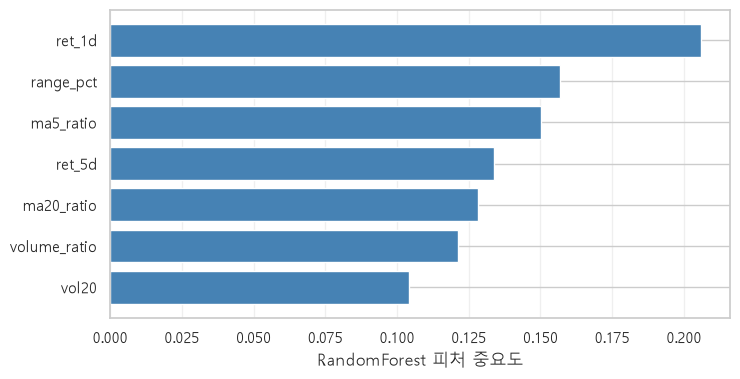

ret_1d          0.2058
range_pct       0.1568
ma5_ratio       0.1502
ret_5d          0.1338
ma20_ratio      0.1281
volume_ratio    0.1211
vol20           0.1042
dtype: float64


In [18]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(imp.index, imp.values, color="steelblue")
ax.set_xlabel("RandomForest 피처 중요도")
ax.grid(alpha=0.3, axis="x")
plt.show()

print(imp.sort_values(ascending=False).round(4))

- **피처 중요도는 모델을 설명하는 근거가 된다**
> 판단 기준을 제시할 때 사용할 수 있다

- **중요도는 인과관계를 뜻하지는 않는다**
> 수익률이 중요하다 → 모델이 수익률을 많이 참조했다는 뜻이지 수익률이 주가를 움직인다는 증거는 아니다!
> 상관된 피처가 여럿이면 중요도가 그들 사이에 나뉘어지기 때문에 각각은 낮게 보여질 수 있다